In [2]:
!pip install datasets

  Using cached datasets-4.5.0-py3-none-any.whl.metadata (19 kB)
  Using cached pyarrow-23.0.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (3.0 kB)
  Using cached multiprocess-0.70.18-py313-none-any.whl.metadata (7.2 kB)
  Using cached dill-0.4.0-py3-none-any.whl.metadata (10 kB)
Using cached datasets-4.5.0-py3-none-any.whl (515 kB)
Using cached multiprocess-0.70.18-py313-none-any.whl (151 kB)
Using cached dill-0.4.0-py3-none-any.whl (119 kB)
Using cached pyarrow-23.0.0-cp313-cp313-macosx_12_0_arm64.whl (34.2 MB)
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 19.0.0
    Uninstalling pyarrow-19.0.0:
      Successfully uninstalled pyarrow-19.0.0
  Attempting uninstall: dill━━━━━━━━━━━━━━━━━━━━━━━━━━ 0/4 [pyarrow]
    Found existing installation: dill 0.3.8━━━━━━━ 0/4 [pyarrow]
    Uninstalling dill-0.3.8:━━━━━━━━━━━━━━━━━━━━━━ 0/4 [pyarrow]
      Successfully uninstalled dill-0.3.8━━━━━━━━━ 0/4 [pyarrow]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [datasets]━━

In [22]:
import numpy as np
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn  as sns
from tqdm import tqdm

sns.set()

In [3]:
data = load_dataset('lmsys/lmsys-chat-1m',split='train')

In [23]:
# for i in range(10):
#     print(data[i]['conversation'][0]['role'])

print(len(data))

1000000


Processing conversations: 100%|████| 1000000/1000000 [01:18<00:00, 12791.81it/s]
/var/folders/4j/h4tbr0nx3x7883_kb4sxg03m0000gn/T/ipykernel_14382/1925532539.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette='viridis')


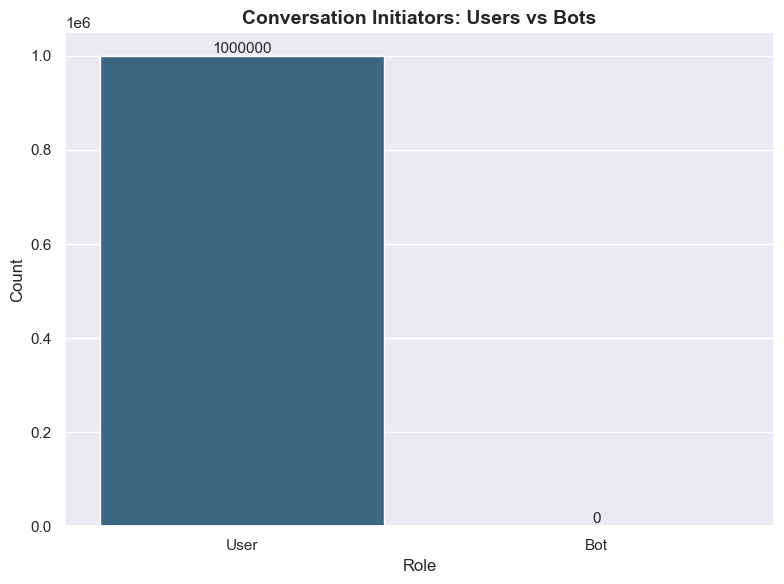


Summary:
User-initiated conversations: 1000000
Bot-initiated conversations: 0
Total conversations: 1000000


In [26]:
def findNumBotsAndUsers(data) -> dict:
    '''
    This function will check for number of users and bots who initiated the conversation
    and visualize the results with a bar plot.
    
    Returns:
        dict: Dictionary containing counts of user and bot initiated conversations
    '''
    users, bots = 0, 0
    
    # Add tqdm progress bar
    for i in tqdm(range(len(data)), desc="Processing conversations"):
        if data[i]['conversation'][0]['role'].lower() == 'user':
            users += 1
        else:
            bots += 1
    
    # Create visualization
    counts = {'User': users, 'Bot': bots}
    
    plt.figure(figsize=(8, 6))
    sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette='viridis')
    plt.title('Conversation Initiators: Users vs Bots', fontsize=14, fontweight='bold')
    plt.xlabel('Role', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    
    # Add value labels on top of bars
    for i, (key, value) in enumerate(counts.items()):
        plt.text(i, value, str(value), ha='center', va='bottom', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\nSummary:")
    print(f"User-initiated conversations: {users}")
    print(f"Bot-initiated conversations: {bots}")
    print(f"Total conversations: {users + bots}")
    
    return counts

# Usage
result = findNumBotsAndUsers(data)

In [35]:
filtered_data = data.filter(lambda example : example['language'] == 'English')
print(len(filtered_data))

Filter:   0%|          | 0/1000000 [00:00<?, ? examples/s]

777453


In [41]:
filtered_data[0]['conversation'][0]

{'content': 'how can identity protection services help protect me against identity theft',
 'role': 'user'}

In [44]:
more_filtered_data = filtered_data.filter(lambda row: 20 < len(row['conversation'][0]['content']) < 200)

Filter:   0%|          | 0/777453 [00:00<?, ? examples/s]

In [45]:
more_filtered_data.shape

(424057, 7)